# Brain Tumor Detection (BR35H 2020)
Binary image classification on BR35H dataset to detect the presence of brain tumors.  
Uses MobileNetV2 with transfer learning and compares results to a Logistic Regression baseline.  
Link to dataset: https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection 

Notebook workflow:
1. Imports
2. Dataset Splitting
3. Data Augmentation + Loading
4. Visualizing Sample Images
5. Data Loader Setup
6. Model Setup (MobileNetV2)
7. Training Loop
8. CNN Test Set Eval
9. Visualize Test Predictions
10. Logistic Regression for Comparison
11. Train and Evaluate LR
12. Comparison of CNN and LR

## 1. Imports 


In [1]:
import os
import shutil
import random

from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
from torchvision import models
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## 2. Dataset Splitting

In [2]:
# Split images into train/validation/test (70/15/15) for each class.
root = "dataset"
yes_dir = os.path.join(root, "yes")
no_dir = os.path.join(root, "no")

target_root = "dataset_split"
splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(target_root, split, "yes"), exist_ok=True)
    os.makedirs(os.path.join(target_root, split, "no"), exist_ok=True)

def split_class(source_dir, class_name):
    images = os.listdir(source_dir)
    random.shuffle(images)
    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(images):
        src = os.path.join(source_dir, img)
        if i < train_end:
            dst = os.path.join(target_root, "train", class_name, img)
        elif i < val_end:
            dst = os.path.join(target_root, "val", class_name, img)
        else:
            dst = os.path.join(target_root, "test", class_name, img)
        shutil.copy(src, dst)

split_class(yes_dir, "yes")
split_class(no_dir, "no")

## 3. Data Augmentation and Loading

In [3]:
#Resize images, apply random flips/rotations, normalize 
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),    
    transforms.RandomRotation(15),        
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = ImageFolder("dataset_split/train", transform=transform)
val_data = ImageFolder("dataset_split/val", transform=transform)
test_data = ImageFolder("dataset_split/test", transform=transform)

print(len(train_data), len(val_data), len(test_data))
print(train_data.classes)

3000 2742 2730
['no', 'yes']


## 4. Visualize Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data

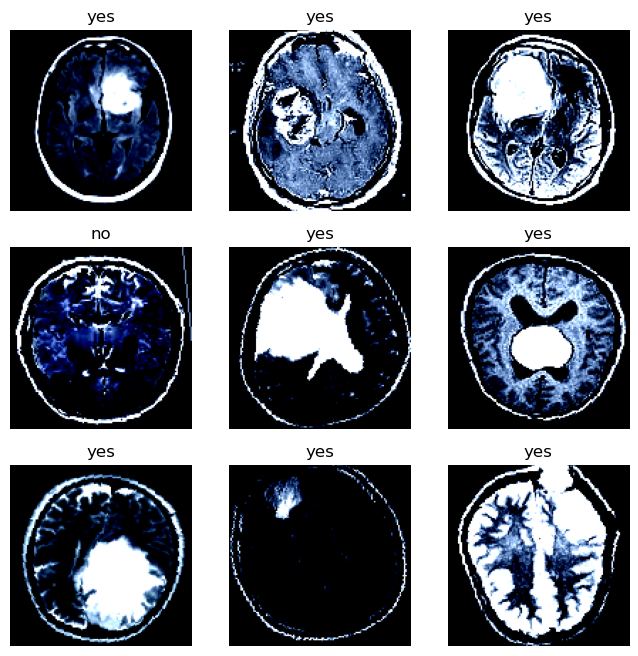

In [4]:
def show_samples(dataset, n=9):
    plt.figure(figsize=(8, 8))
    for i in range(n):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]
        plt.subplot(3, 3, i+1)
        plt.imshow(img.permute(1, 2, 0))  
        plt.title(dataset.classes[label])
        plt.axis("off")
    plt.show()
show_samples(train_data)

## 5. Data loader setup

In [5]:
batch_size = 16

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, num_workers=0)
test_loader = DataLoader(test_data, batch_size=16, shuffle=True, num_workers=0)

## 6. Model Setup (MobileNetV2)

In [6]:
# Use MPS backend if available (Done on Apple M1)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [7]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

#Freeze the base 
for param in model.features.parameters():
    param.requires_grad = False

#Unfreeze last 3 blocks
for layer in model.features[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace the classifier for binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)


## 7. Training Loop
Binary Cross Entropy Loss with logits.
Track accuracy, precision, recall, F1 on train/val.

In [8]:
epochs = 10 
learning_rate = 1e-4

#Criterion & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=learning_rate
)

#Training loop
for epoch in range(epochs):
    model.train()
    train_losses = []
    all_preds = []
    all_labels = []

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # shape [batch, 1]

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        preds = torch.sigmoid(outputs).detach().cpu() >= 0.5
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    #Metrics
    train_acc = accuracy_score(all_labels, all_preds)
    train_prec = precision_score(all_labels, all_preds)
    train_rec = recall_score(all_labels, all_preds)
    train_f1 = f1_score(all_labels, all_preds)

    #Validation
    model.eval()
    val_losses = []
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_losses.append(loss.item())

            preds = torch.sigmoid(outputs).detach().cpu() >= 0.5
            val_preds.extend(preds.numpy())
            val_labels.extend(labels.detach().cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_prec = precision_score(val_labels, val_preds)
    val_rec = recall_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {sum(train_losses)/len(train_losses):.4f} "
          f"Val Loss: {sum(val_losses)/len(val_losses):.4f} "
          f"Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f} "
          f"F1: {val_f1:.4f}")


100%|██████████| 188/188 [00:16<00:00, 11.42it/s]


Epoch [1/10] Train Loss: 0.2908 Val Loss: 0.1298 Train Acc: 0.8733 Val Acc: 0.9540 F1: 0.9534


100%|██████████| 188/188 [00:19<00:00,  9.89it/s]


Epoch [2/10] Train Loss: 0.1837 Val Loss: 0.0844 Train Acc: 0.9283 Val Acc: 0.9730 F1: 0.9729


100%|██████████| 188/188 [00:13<00:00, 14.43it/s]


...

Epoch [8/10] Train Loss: 0.0736 Val Loss: 0.0266 Train Acc: 0.9760 Val Acc: 0.9916 F1: 0.9916


100%|██████████| 188/188 [00:15<00:00, 12.17it/s]


Epoch [9/10] Train Loss: 0.0701 Val Loss: 0.0217 Train Acc: 0.9737 Val Acc: 0.9934 F1: 0.9934


100%|██████████| 188/188 [00:13<00:00, 13.85it/s]


Epoch [10/10] Train Loss: 0.0539 Val Loss: 0.0290 Train Acc: 0.9813 Val Acc: 0.9905 F1: 0.9904


In [19]:
torch.save(model.state_dict(), "model.pth")

## 8. Test Set Evaluation
Compute classification report and confusion matrix.
Visualize predictions on test images (denormalized).

Test Set Metrics:
              precision    recall  f1-score   support

          no       0.98      1.00      0.99      1363
         yes       1.00      0.98      0.99      1367

    accuracy                           0.99      2730
   macro avg       0.99      0.99      0.99      2730
weighted avg       0.99      0.99      0.99      2730



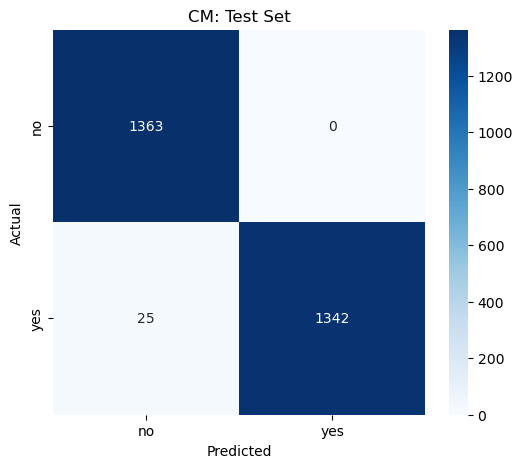

In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).int()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#Classification report 
print("Test Set Metrics:")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

#Confusion matrix 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM: Test Set")
plt.show()


## 9. Visualize Test Predictions

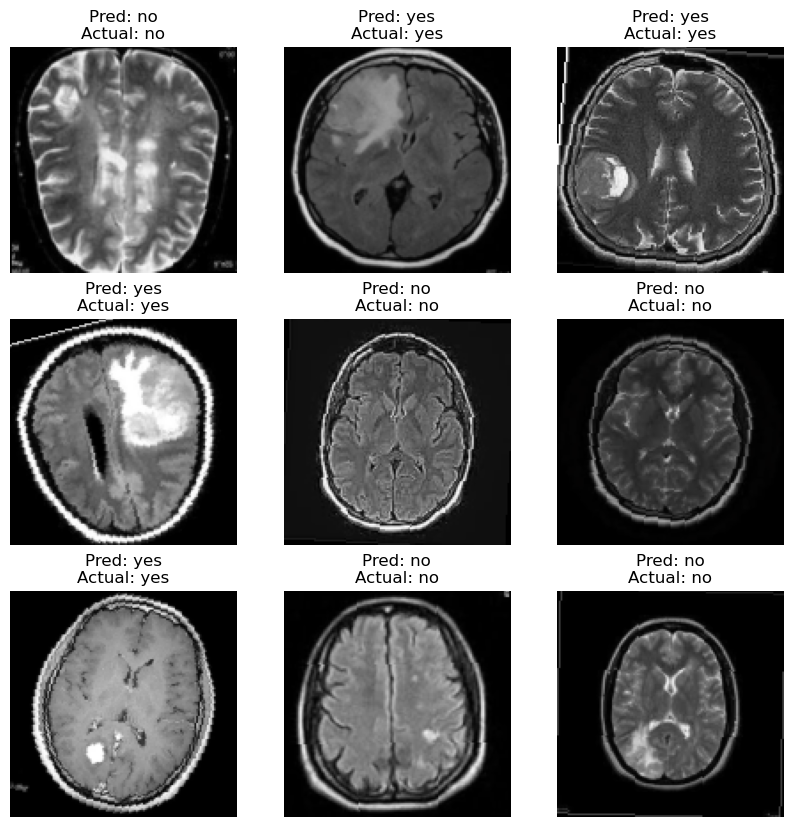

In [15]:
def show_test_predictions(loader, n=9):
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3,1,1)
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
    outputs = torch.sigmoid(model(images))
    preds = (outputs >= 0.5).int()

    plt.figure(figsize=(10,10))
    for i in range(n):
        img = images[i]
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img = img.permute(1,2,0)  

        plt.subplot(3,3,i+1)
        plt.imshow(img.cpu())  
        plt.title(f"Pred: {train_data.classes[preds[i].item()]}\nActual: {train_data.classes[int(labels[i].item())]}")
        plt.axis("off")
    plt.show()

show_test_predictions(test_loader, n=9)

## 10. Logistic Regression for Comparison
Flatten images, convert to grayscale, train 

In [16]:
transform_lr = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(),      
    transforms.ToTensor()
])

train_data_lr = ImageFolder("dataset_split/train", transform=transform_lr)
val_data_lr = ImageFolder("dataset_split/val", transform=transform_lr)
test_data_lr = ImageFolder("dataset_split/test", transform=transform_lr)

def flatten_dataset(dataset):
    X, y = [], []
    for img, label in dataset:
        X.append(img.view(-1).numpy()) 
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = flatten_dataset(train_data_lr)
X_val, y_val = flatten_dataset(val_data_lr)
X_test, y_test = flatten_dataset(test_data_lr)


## 11. Train & Evaluate LR


Train Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1500
         yes       0.96      0.96      0.96      1500

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000


Validation Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1372
         yes       0.96      0.96      0.96      1370

    accuracy                           0.96      2742
   macro avg       0.96      0.96      0.96      2742
weighted avg       0.96      0.96      0.96      2742


Test Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1363
         yes       0.96      0.96      0.96      1367

    accuracy                           0.96      2730
   macro avg       0.96      0.96      0.96      2730
weighted avg       0.9

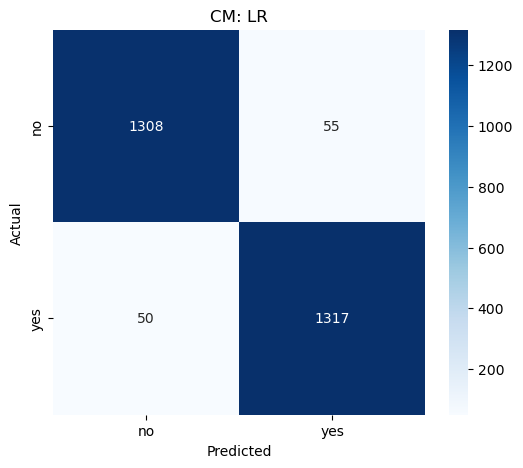

In [17]:
logreg = LogisticRegression(max_iter=2000, solver='saga', C=1.0, n_jobs=-1)
logreg.fit(X_train, y_train)

for name, X, y in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    pred = logreg.predict(X)
    print(f"\n{name} Metrics:")
    print(classification_report(y, pred, target_names=train_data_lr.classes))

cm = confusion_matrix(y_test, logreg.predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data_lr.classes,
            yticklabels=train_data_lr.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM: LR")
plt.show()

## 12. Comparison of CNN and LR

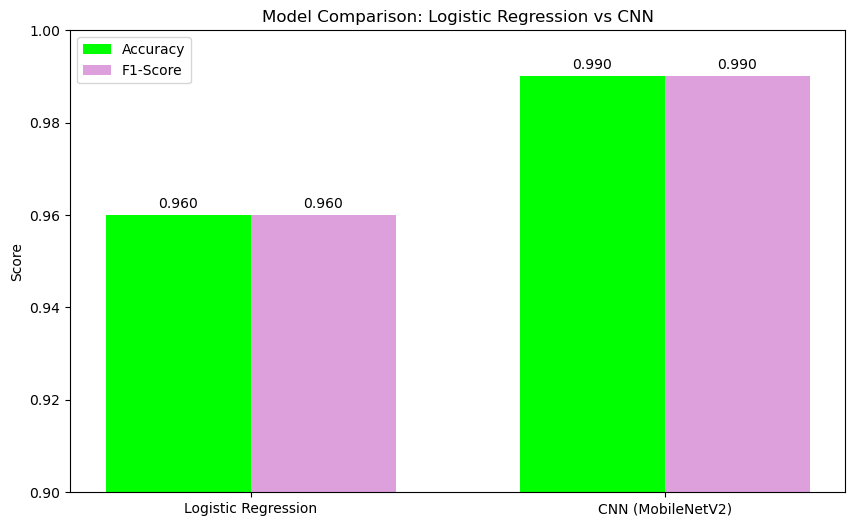

In [18]:
models = ['Logistic Regression', 'CNN (MobileNetV2)']
accuracies = [0.96, 0.99]
f1_scores = [0.96, 0.99]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='lime')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='plum')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs CNN')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.9, 1.0])

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()